In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys 
# import scikitplot as skplt
import scipy.stats as stats
import pickle
from sklearn.ensemble import IsolationForest
import joblib
from sklearn.preprocessing import StandardScaler

In [2]:
os.chdir("C:/Users/sergi/Documents/Pruebas Técnicas/Nequi DS/Analisis_fraude/analisis-fraude/")


In [3]:
import src.analisis_fraude.pipelines.preprocessing.nodes as processing
import src.analisis_fraude.pipelines.models.nodes as models

In [4]:
params=catalog.load("parameters")

NameError: name 'catalog' is not defined

## Lectura

In [26]:
%%time
file_path = "data/01_raw/sample_data_0006_part_00.parquet" # todos los datos
data = pd.read_parquet(file_path)

CPU times: total: 24.6 s
Wall time: 46 s


In [27]:
data= data.sample(n=10000, random_state=42)

## Preprocesing

Este archivo contiene las siguientes funciones:

clean_data: Limpia los datos, eliminando valores nulos y transformando formatos.
feature_engineering: Crea variables derivadas como:
Indicador de fin de semana.
Ventanas temporales de 24 horas.
Suma, promedio y frecuencia de transacciones.
scaling: Escala las variables numéricas usando StandardScaler.

In [28]:
# Aplicar las funciones
print("\nLimpieza de datos...")
cleaned_data = processing.clean_data(data)
cleaned_data.head(5)


Limpieza de datos...


,merchant_id,_id,subsidiary,transaction_date,account_number,user_id,transaction_amount,transaction_type
1081054,075d178871d8d48502bf1f54887e52fe,b69a8ad1a8280b8e6f0bd38b4cce8a4a,a8bd47b85e2b946052d816b208b3f0a4,2021-06-28 16:26:07,cb8cc7fef9d4410878603dad13f54cf5,ba11d753ac9444bc5f03fbd9fd98d923,594.44550123,DEBITO
2471502,817d18cd3c31e40e9bff0566baae7758,650dcc8f0c905205f35b65d7ac5998b2,540c5783008d512771471e186f77d9be,2021-10-14 18:12:15,344adb90dd50281461e4429b69ce6eb3,4968649a6a6db0989e193923c1436c09,118.88910024,DEBITO
6868479,817d18cd3c31e40e9bff0566baae7758,87be795748f41e4a4a97d783ce1f14cf,e3a9434b7e145d952d296cb255055b0f,2021-04-06 15:21:37,22cd1818eb77a5f0e25aacbfde8b24bf,15325b33069a73ac4ee0f6bf5e30d6fb,356.66730074,DEBITO
9424293,838a8fa992a4aa2fb5a0cf8b15b63755,d99542642ab30f13a7676c46b423ea22,207693b4bb0a84615b2a4f002a483b0a,2021-08-16 14:59:33,ea9122c8693053dea289a414caab5521,96e95977ba74cd6a2d0cf76bb6a9b3b5,271.86727220,CREDITO
6613222,817d18cd3c31e40e9bff0566baae7758,be7fd6155c65aeb95df167bf07dffd90,855e9baef9ba84ed74598c5a7de076d7,2021-09-17 20:39:45,22a07e37f9b02910126f702115884931,8b933efcc209a3269003ec7975b8a9a5,59.44455012,DEBITO


In [29]:
print("\nGeneración de variables derivadas...")
features = processing.feature_engineering(cleaned_data)
features.head(5)


Generación de variables derivadas...


C:\Users\sergi\Documents\Pruebas Técnicas\Nequi DS\Analisis_fraude\analisis-fraude\src\analisis_fraude\pipelines\preprocessing\nodes.py:60: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  clean_data.loc[:, 'window_24h'] = clean_data['transaction_date'].dt.floor('24H')


,merchant_id,_id,subsidiary,transaction_date,account_number,user_id,transaction_amount,transaction_type,year,month,day,time_diff,day_of_week,is_weekend,window_24h,total_amount,transaction_count,average_amount,std_amount
0,838a8fa992a4aa2fb5a0cf8b15b63755,8ae339d486d241b083da92151bbad9f9,f54e0b6b32831a6307361ed959903e76,2021-02-05 12:24:34,5aec5c8648955b256f7289735ab986f0,24bf52f1e2b0616eb9f279fadf73afa5,-0.565366,DEBITO,2021,2,5,0.138179,4,0,2021-02-05,5.94445501,1,5.944455,NaN
1,838a8fa992a4aa2fb5a0cf8b15b63755,e07bd7b606a1be24d55d37c2aa71cacb,d4b621a24cc03e3f92155a7e241fa1c3,2021-02-13 15:43:51,5f885e75bc34296f7c261ec5b1289beb,8f79b890b160711088967398e35b9252,-0.461518,DEBITO,2021,2,13,0.014311,5,1,2021-02-13,22.11337264,1,22.113373,NaN
2,838a8fa992a4aa2fb5a0cf8b15b63755,c43f66fcd4172bca435b5e8af14ba514,d4b621a24cc03e3f92155a7e241fa1c3,2021-01-05 12:58:46,5e9d5252baa6801de277305aa2fcfeaa,ccd856b4075077657f336d1aa626f56b,-0.565366,CREDITO,2021,1,5,-0.140934,1,0,2021-01-05,5.94445501,1,5.944455,NaN
3,838a8fa992a4aa2fb5a0cf8b15b63755,9059f5341cb5f28893a9a739d6c5eb31,d4b621a24cc03e3f92155a7e241fa1c3,2021-02-16 14:01:24,5aec5c8648955b256f7289735ab986f0,24bf52f1e2b0616eb9f279fadf73afa5,-0.565366,DEBITO,2021,2,16,0.126612,1,0,2021-02-16,5.94445501,1,5.944455,NaN
4,838a8fa992a4aa2fb5a0cf8b15b63755,5dd1991276d30cc92c12317c8e997fd8,f54e0b6b32831a6307361ed959903e76,2021-01-11 10:48:00,34355700491baab07bc889821ce82c88,ea36979228a4393d63884e01023f1514,-0.565343,CREDITO,2021,1,11,-0.400214,0,0,2021-01-11,5.94802168,1,5.948022,NaN


In [30]:
print("\nEscalado de variables...")
normalize_features = processing.normalize_features(features)
normalize_features.head()



Escalado de variables...


C:\Users\sergi\Documents\Pruebas Técnicas\Nequi DS\Analisis_fraude\analisis-fraude\src\analisis_fraude\pipelines\preprocessing\nodes.py:124: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_data[features] = feature_data[features].apply(pd.to_numeric, errors='coerce')


,merchant_id,_id,subsidiary,transaction_date,account_number,user_id,transaction_amount,transaction_type,year,month,day,time_diff,day_of_week,is_weekend,window_24h,total_amount,transaction_count,average_amount,std_amount
3,838a8fa992a4aa2fb5a0cf8b15b63755,9059f5341cb5f28893a9a739d6c5eb31,d4b621a24cc03e3f92155a7e241fa1c3,2021-02-16 14:01:24,5aec5c8648955b256f7289735ab986f0,24bf52f1e2b0616eb9f279fadf73afa5,-0.452909,DEBITO,2021,2,16,1.162812,1,0,2021-02-16,5.94445501,1,5.944455,NaN
44,838a8fa992a4aa2fb5a0cf8b15b63755,0f146cbf3c09c570e41f37bcf19feba7,f54e0b6b32831a6307361ed959903e76,2021-01-23 20:05:27,2a77707d2f542ec2ab9700a8389ee114,f5827c28fa4a5bd9b9e3a82366b12e44,1.788771,CREDITO,2021,1,23,1.014705,5,1,2021-01-23,17.83336503,1,17.833365,NaN
81,838a8fa992a4aa2fb5a0cf8b15b63755,07347c338582bf73f4d18aadc6c04c95,f54e0b6b32831a6307361ed959903e76,2021-02-14 10:39:51,f796e28e2884eeed40fb7ab3457ff889,11044f60596286a6bb3d25bef7909a10,-0.430492,DEBITO,2021,2,14,-0.619186,6,1,2021-02-14,12.00779912,2,6.0039,0.084067
115,838a8fa992a4aa2fb5a0cf8b15b63755,15a6d67379407b8a64f1dc8b072161c8,d4b621a24cc03e3f92155a7e241fa1c3,2021-02-12 18:12:29,f796e28e2884eeed40fb7ab3457ff889,11044f60596286a6bb3d25bef7909a10,-0.452909,DEBITO,2021,2,12,-0.880785,4,0,2021-02-12,5.94445501,1,5.944455,NaN
124,838a8fa992a4aa2fb5a0cf8b15b63755,7e3969600260dba7482ce68440491a76,dff70ce33784a932ce4a7efc81a43863,2021-01-12 07:59:47,cd6d04f6ffa5f16a55dc9a26e588bfc1,7a4740d97e9f869ed3c044a3607aff4b,-0.452461,DEBITO,2021,1,12,-0.677546,1,0,2021-01-12,11.89247669,2,5.946238,0.000841


# Models 

In [32]:
data_with_anomalies, isolation_forest_model=models.train_isolation_forest(normalize_features, features, model_params)

AttributeError: module 'src.analisis_fraude.pipelines.models.nodes' has no attribute 'train_isolation_forest'

In [ ]:
# Definir las rutas de salida
result_path = 'data/07_model_output/anomaly_detection_results.csv'
model_path = 'data/06_models/isolation_forest_model_v2.pkl'

# Llamar a la función para guardar resultados
save_results(data_with_anomalies, isolation_forest_model, result_path, model_path)

In [7]:
# Aplicar las funciones
print("\nLimpieza de datos...")
cleaned_data = clean_data(data)
print(cleaned_data.head())


Limpieza de datos...
                        merchant_id                               _id  \
0  075d178871d8d48502bf1f54887e52fe  aa8dacff663072244d0a8ab6bbe36b93   
1  075d178871d8d48502bf1f54887e52fe  a53bb81bd0bba2ae2535bda7ea5a550c   
2  075d178871d8d48502bf1f54887e52fe  79f893ea65c06fe2933f3847c88c272f   
3  075d178871d8d48502bf1f54887e52fe  ce577223699dbdc119df2ab8a35457fe   
4  075d178871d8d48502bf1f54887e52fe  0ce7ab2950e7a788a608f881aec0f8f0   

                         subsidiary    transaction_date  \
0  824b2af470cbe6a65b15650e03b740fc 2021-09-12 18:32:03   
1  2d8d34be7509a6b1262336d036fdb324 2021-09-12 18:31:58   
2  5eeb18254850b21af0a6bb2697913cd3 2021-09-12 18:31:56   
3  5221a599856c0a0588ed9ffd150edd3b 2021-09-12 18:31:10   
4  971e55ef12d80ec070ea4f6750c8b892 2021-09-12 18:31:07   

                     account_number                           user_id  \
0  648e257c9d74909a1f61c54b93a9e1b3  ba42d192a145583ba8e7bf04875f837f   
1  c0b62f9046c83ea5543ea46a497a4d6e  5

In [9]:
print("\nGeneración de variables derivadas...")
features = feature_engineering(cleaned_data)
print(features.head())



Generación de variables derivadas...
                        merchant_id                               _id  \
0  075d178871d8d48502bf1f54887e52fe  84a07b1ddbb4ad36af95de852538f07b   
1  075d178871d8d48502bf1f54887e52fe  41360e65057396d7fbae670cf24c7532   
2  075d178871d8d48502bf1f54887e52fe  8ffce3441ea2e1def8cf3c975bef39d9   
3  075d178871d8d48502bf1f54887e52fe  01adaa303b60d5e7d802969a93757328   
4  075d178871d8d48502bf1f54887e52fe  c9b77370d49148c6f659adfacf2a643e   

                         subsidiary    transaction_date  \
0  64499ecc97e11acce26421efec265be8 2021-09-12 18:24:43   
1  783d126bd093e7a16eabd2e006559def 2021-09-12 18:22:39   
2  64499ecc97e11acce26421efec265be8 2021-09-12 18:21:50   
3  05a64aedcb74100d8e4d2c6eccd8d830 2021-09-12 16:56:29   
4  05a64aedcb74100d8e4d2c6eccd8d830 2021-09-12 16:54:50   

                     account_number                           user_id  \
0  612e0f7b87af399d0c2aaa91551a10bf  7b1711df3fac51a3473ed7d12cc137db   
1  15c7c41a4e526f2457a

In [10]:
features.to_parquet('data/01_raw/features.parquet')

In [15]:
print("\nEscalado de variables...")
normalize_features = normalize_features(features)
print(scaled_data.head())


Escalado de variables...


/var/tmp/ipykernel_31628/4170965197.py:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_data[features] = feature_data[features].apply(pd.to_numeric, errors='coerce')


                        merchant_id                               _id  \
0  075d178871d8d48502bf1f54887e52fe  84a07b1ddbb4ad36af95de852538f07b   
1  075d178871d8d48502bf1f54887e52fe  41360e65057396d7fbae670cf24c7532   
2  075d178871d8d48502bf1f54887e52fe  8ffce3441ea2e1def8cf3c975bef39d9   
3  075d178871d8d48502bf1f54887e52fe  01adaa303b60d5e7d802969a93757328   
4  075d178871d8d48502bf1f54887e52fe  c9b77370d49148c6f659adfacf2a643e   

                         subsidiary    transaction_date  \
0  64499ecc97e11acce26421efec265be8 2021-09-12 18:24:43   
1  783d126bd093e7a16eabd2e006559def 2021-09-12 18:22:39   
2  64499ecc97e11acce26421efec265be8 2021-09-12 18:21:50   
3  05a64aedcb74100d8e4d2c6eccd8d830 2021-09-12 16:56:29   
4  05a64aedcb74100d8e4d2c6eccd8d830 2021-09-12 16:54:50   

                     account_number                           user_id  \
0  612e0f7b87af399d0c2aaa91551a10bf  7b1711df3fac51a3473ed7d12cc137db   
1  15c7c41a4e526f2457a3ac7523289c9a  6372013af2e3f186af98c2f

In [10]:
cleaned_data.to_parquet('data/01_raw/cleaned_data.parquet')

In [16]:
normalize_features.to_parquet('data/01_raw/normalize_features.parquet')

## Model

In [17]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import joblib

def train_isolation_forest(data: pd.DataFrame, features: list, model_params: dict) -> tuple:
    """
    Entrena un modelo Isolation Forest y genera predicciones.

    Args:
        data (pd.DataFrame): Datos procesados para entrenamiento.
        features (list): Lista de características a usar en el modelo.
        model_params (dict): Parámetros del modelo Isolation Forest.

    Returns:
        tuple: DataFrame con las predicciones y el modelo entrenado.
    """
    # Entrenar el modelo
    model = IsolationForest(**model_params)
    data['anomaly_score'] = model.fit_predict(data[features])

    return data, model


def save_results(data: pd.DataFrame, model, result_path: str, model_path: str):
    """
    Guarda los resultados y el modelo entrenado.

    Args:
        data (pd.DataFrame): Datos con predicciones.
        model: Modelo entrenado.
        result_path (str): Ruta para guardar resultados.
        model_path (str): Ruta para guardar el modelo.
    """
    # Guardar resultados
    data[['user_id', 'transaction_date', 'transaction_amount', 'anomaly_score']].to_csv(result_path, index=False)

    # Guardar el modelo
    joblib.dump(model, model_path)

    print(f"Results saved to {result_path}")
    print(f"Model saved to {model_path}")


### Prueba

In [48]:
# Lista de características seleccionadas
features = ['transaction_amount', 'time_diff']

# Parámetros para Isolation Forest
model_params = {
    'n_estimators': 150,
    'contamination': 0.08,
    'random_state': 42
}


In [ ]:
data_with_anomalies, isolation_forest_model=train_isolation_forest(normalize_features, features, model_params)

In [ ]:
# Definir las rutas de salida
result_path = 'data/07_model_output/anomaly_detection_results.csv'
model_path = 'data/06_models/isolation_forest_model_v2.pkl'

# Llamar a la función para guardar resultados
save_results(data_with_anomalies, isolation_forest_model, result_path, model_path)


In [ ]:
# Trazar un histograma
plt.figure(figsize=(10, 6))
sns.histplot(data_with_anomalies['anomaly_score'], kde=True, bins=30, color='blue')
plt.title('Distribución de Puntuaciones de Anomalía')
plt.xlabel('Puntuación de Anomalía')
plt.ylabel('Frecuencia')
plt.show()

In [39]:
# Calcular el percentil 75 de los puntajes de anomalía
percentil_75 = data_with_anomalies['anomaly_score'].quantile(0.25)

print(f"Umbral para el percentil 75: {percentil_75}")

# Identificar anomalías (valores por encima del percentil 75)
data_with_anomalies['is_anomalous'] = data_with_anomalies['anomaly_score'] > percentil_75

# Resumen de anomalías detectadas
anomalies = data_with_anomalies[data_with_anomalies['is_anomalous']]
print(f"Total de anomalías detectadas: {len(anomalies)}")


Umbral para el percentil 75: 1.0
Total de anomalías detectadas: 0


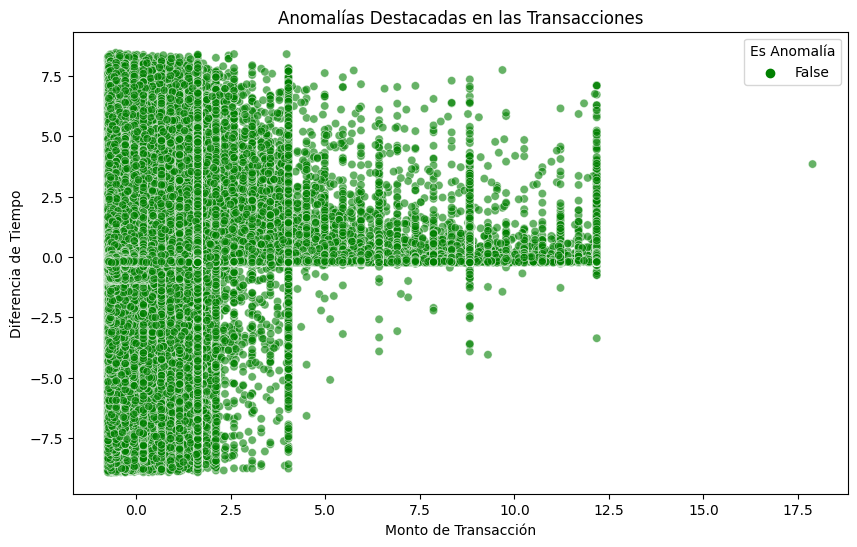

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=data_with_anomalies['transaction_amount'],
    y=data_with_anomalies['time_diff'],
    hue=data_with_anomalies['is_anomalous'],
    palette={True: 'red', False: 'green'},
    alpha=0.6
)
plt.title('Anomalías Destacadas en las Transacciones')
plt.xlabel('Monto de Transacción')
plt.ylabel('Diferencia de Tiempo')
plt.legend(title='Es Anomalía')
plt.show()


In [40]:
# Ajustar el umbral a partir del percentil 90
percentil_90 = data_with_anomalies['anomaly_score'].quantile(0.95)

print(f"Umbral para el percentil 90: {percentil_90}")

# Identificar anomalías con nuevo umbral
data_with_anomalies['is_anomalous'] = data_with_anomalies['anomaly_score'] > percentil_90


Umbral para el percentil 90: 1.0


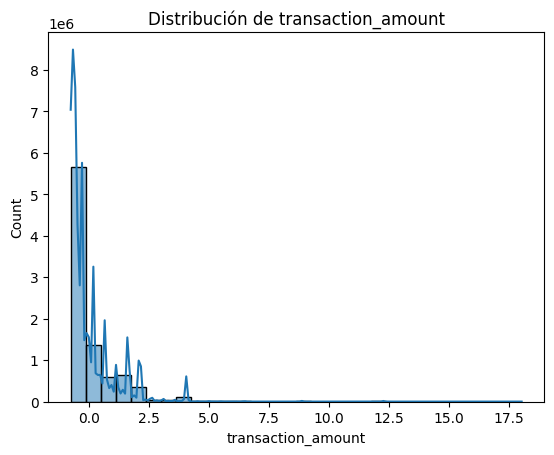

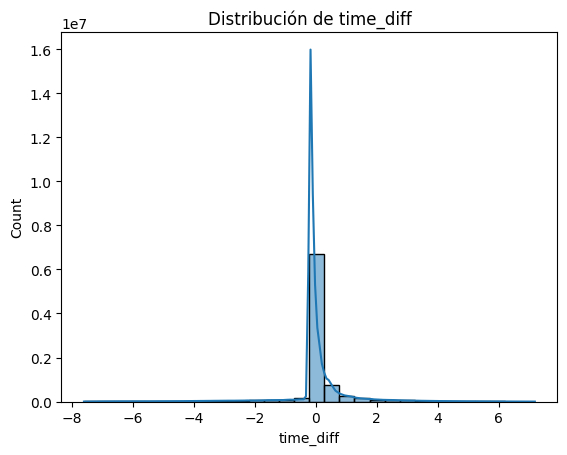

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizar la distribución de transaction_amount
sns.histplot(data['transaction_amount'], kde=True, bins=30)
plt.title('Distribución de transaction_amount')
plt.show()

# Visualizar la distribución de time_diff
sns.histplot(data['time_diff'], kde=True, bins=30)
plt.title('Distribución de time_diff')
plt.show()


In [46]:
# Promedio histórico por usuario
data['mean_amount_user'] = data.groupby('user_id')['transaction_amount'].transform('mean')

# Desviación estándar por usuario
data['std_amount_user'] = data.groupby('user_id')['transaction_amount'].transform('std')

# Relación entre transacción actual y promedio histórico
data['amount_ratio'] = data['transaction_amount'] / data['mean_amount_user']

# Número de transacciones en una ventana de 24 horas
data['transaction_count_24h'] = data.groupby(['user_id', 'window_24h'])['transaction_amount'].transform('count')


In [47]:
from sklearn.metrics import classification_report

# Supongamos que tienes una columna con etiquetas reales: 'true_label' (1 para anómalas, 0 para normales)
print(classification_report(data['true_label'], data['is_anomalous']))


KeyError: 'true_label'

## Sandbox Model 2 dbscan (No se obtuvieron los resultados deseados)

In [43]:
%%time
file_path_cleaned_data = "data/01_raw/features.parquet"
data = pd.read_parquet(file_path_cleaned_data)

CPU times: user 15.7 s, sys: 20.6 s, total: 36.3 s
Wall time: 19.1 s


In [44]:
data.shape

(8804378, 19)

In [5]:
prueba=scaled_data.sample(n=70000, random_state=42)

In [18]:
prueba

,merchant_id,_id,subsidiary,transaction_date,account_number,user_id,transaction_amount,transaction_type,day_of_week,is_weekend,window_24h,total_amount,transaction_count,average_amount,cluster
1081054,075d178871d8d48502bf1f54887e52fe,b69a8ad1a8280b8e6f0bd38b4cce8a4a,a8bd47b85e2b946052d816b208b3f0a4,2021-06-28 16:26:07,cb8cc7fef9d4410878603dad13f54cf5,ba11d753ac9444bc5f03fbd9fd98d923,1.673348,DEBITO,0,0,2021-06-28,1.935969,-0.103583,1.741535,0
2471502,817d18cd3c31e40e9bff0566baae7758,650dcc8f0c905205f35b65d7ac5998b2,540c5783008d512771471e186f77d9be,2021-10-14 18:12:15,344adb90dd50281461e4429b69ce6eb3,4968649a6a6db0989e193923c1436c09,-0.301035,DEBITO,3,0,2021-10-14,-0.367405,-0.176054,-0.313302,0
6868479,817d18cd3c31e40e9bff0566baae7758,87be795748f41e4a4a97d783ce1f14cf,e3a9434b7e145d952d296cb255055b0f,2021-04-06 15:21:37,22cd1818eb77a5f0e25aacbfde8b24bf,15325b33069a73ac4ee0f6bf5e30d6fb,0.686156,DEBITO,1,0,2021-04-06,0.144456,-0.176054,0.714117,0
9424293,838a8fa992a4aa2fb5a0cf8b15b63755,d99542642ab30f13a7676c46b423ea22,207693b4bb0a84615b2a4f002a483b0a,2021-08-16 14:59:33,ea9122c8693053dea289a414caab5521,96e95977ba74cd6a2d0cf76bb6a9b3b5,0.334089,CREDITO,0,0,2021-08-16,-0.038091,-0.176054,0.347703,0
6613222,817d18cd3c31e40e9bff0566baae7758,be7fd6155c65aeb95df167bf07dffd90,855e9baef9ba84ed74598c5a7de076d7,2021-09-17 20:39:45,22a07e37f9b02910126f702115884931,8b933efcc209a3269003ec7975b8a9a5,-0.547833,DEBITO,4,0,2021-09-17,-0.495370,-0.176054,-0.570157,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7235104,817d18cd3c31e40e9bff0566baae7758,bf58901ddddaef04be081437c6693979,8c5cf0f962e028e1e116c910c2cb7f21,2021-08-24 16:50:38,4cece97e981294624366c51efdbab31a,c62a434ab238a4aa38703ac23d998b06,0.044482,DEBITO,1,0,2021-08-24,-0.188253,-0.176054,0.046295,0
7894630,817d18cd3c31e40e9bff0566baae7758,04aeb0d2b290306ba0287a5f1367beba,2d8ce2ed1c2a85aef6e9f9723992dfa4,2021-10-25 06:31:49,93f487e732ecffdfc00b09d35e17e965,a5fddb97234c12ac48f6013aa3c82350,-0.301035,DEBITO,0,0,2021-10-25,-0.367405,-0.176054,-0.313302,0
4937289,817d18cd3c31e40e9bff0566baae7758,cd62304c97933a5b7573ac4e9ac66b91,991240f216218770f1631f741530b05c,2021-08-24 13:01:53,7389914c606aad54601b2a92ab11a3ca,c0e6f259a4dd477fb1b1c7cfed8ba8df,-0.004878,DEBITO,1,0,2021-08-24,-0.213847,-0.176054,-0.005076,0
982145,075d178871d8d48502bf1f54887e52fe,76e1e8907c3355e40a48d3d371afd6c1,16ed27498ff3c944a0df2070ba38ae09,2021-10-23 09:46:33,ecb5ffe508b1dc024f0e103aba9a81a4,5ccb291eb3a20f025164a4fd58d24211,-0.024621,CREDITO,5,1,2021-10-23,-0.224084,-0.176054,-0.025625,0


In [6]:
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def train_dbscan(data: pd.DataFrame, eps: float = 0.5, min_samples: int = 5) -> DBSCAN:
    """
    Entrena un modelo DBSCAN con los datos proporcionados.

    Args:
        data (pd.DataFrame): Datos escalados listos para el modelo.
        eps (float): Radio de vecindad para considerar puntos densos.
        min_samples (int): Número mínimo de puntos para formar un clúster.

    Returns:
        DBSCAN: Modelo entrenado.
    """
    # Seleccionar solo las columnas relevantes para clustering
    clustering_data = data[["transaction_amount", "total_amount", "average_amount", "transaction_count"]]
    
    # Instanciar y entrenar el modelo
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan.fit(clustering_data)
    
    return dbscan


def evaluate_clusters(model: DBSCAN, data: pd.DataFrame) -> pd.DataFrame:
    """
    Evalúa los resultados del modelo DBSCAN y añade etiquetas de clúster al dataset.

    Args:
        model (DBSCAN): Modelo entrenado.
        data (pd.DataFrame): Datos originales o escalados.

    Returns:
        pd.DataFrame: Datos con etiquetas de clúster.
    """
    # Obtener etiquetas de los clústeres
    data["cluster"] = model.labels_
    
    # Contar puntos etiquetados como ruido
    noise_points = sum(data["cluster"] == -1)
    print(f"Puntos considerados ruido: {noise_points}")
    
    return data


def plot_distance_graph(data: pd.DataFrame, k: int = 4):
    """
    Genera un gráfico de distancias para ayudar a determinar un buen valor de eps.

    Args:
        data (pd.DataFrame): Datos escalados listos para clustering.
        k (int): Número de vecinos para calcular la distancia.
    """
    from sklearn.neighbors import NearestNeighbors

    # Seleccionar columnas relevantes
    clustering_data = data[["transaction_amount", "total_amount", "average_amount", "transaction_count"]]
    
    # Calcular las distancias a los k-vecinos más cercanos
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(clustering_data)
    distances, _ = neighbors_fit.kneighbors(clustering_data)
    
    # Ordenar las distancias de manera descendente
    distances = np.sort(distances[:, k-1], axis=0)
    
    # Graficar las distancias
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.title("Gráfico de distancias k-vecinos")
    plt.xlabel("Puntos ordenados")
    plt.ylabel(f"Distancia al {k}-ésimo vecino")
    plt.show()


In [7]:
# Probar el modelo DBSCAN
print("Entrenando el modelo DBSCAN...")
dbscan_model = train_dbscan(prueba, eps=0.5, min_samples=5)

Entrenando el modelo DBSCAN...


In [13]:

# Evaluar los resultados del modelo
print("Evaluando los clústeres generados...")
clustered_data = evaluate_clusters(dbscan_model, prueba)


Evaluando los clústeres generados...
Puntos considerados ruido: 179


Generando gráfico de distancias para ajuste de eps...


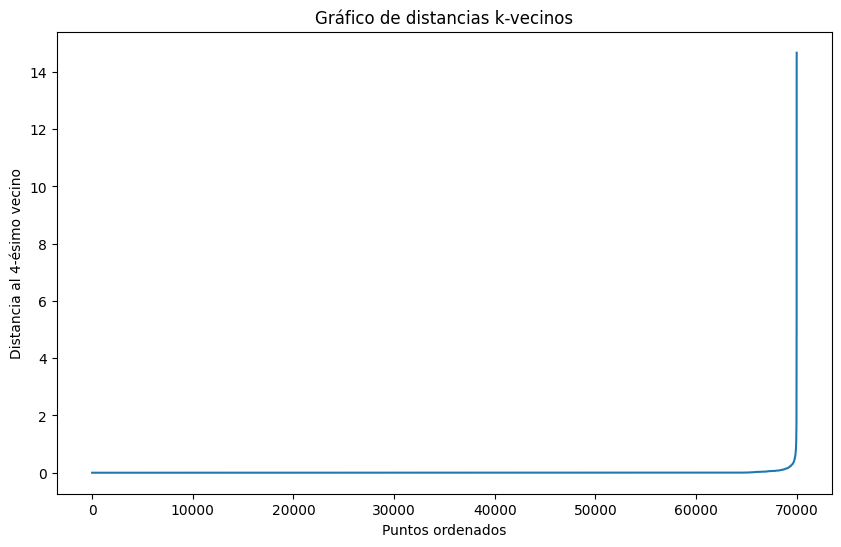

In [9]:
# Gráfico de distancias para ajustar eps
print("Generando gráfico de distancias para ajuste de eps...")
plot_distance_graph(prueba, k=4)


In [14]:
print("Datos con etiquetas de clúster:")
clustered_data

Datos con etiquetas de clúster:


,merchant_id,_id,subsidiary,transaction_date,account_number,user_id,transaction_amount,transaction_type,day_of_week,is_weekend,window_24h,total_amount,transaction_count,average_amount,cluster
1081054,075d178871d8d48502bf1f54887e52fe,b69a8ad1a8280b8e6f0bd38b4cce8a4a,a8bd47b85e2b946052d816b208b3f0a4,2021-06-28 16:26:07,cb8cc7fef9d4410878603dad13f54cf5,ba11d753ac9444bc5f03fbd9fd98d923,1.673348,DEBITO,0,0,2021-06-28,1.935969,-0.103583,1.741535,0
2471502,817d18cd3c31e40e9bff0566baae7758,650dcc8f0c905205f35b65d7ac5998b2,540c5783008d512771471e186f77d9be,2021-10-14 18:12:15,344adb90dd50281461e4429b69ce6eb3,4968649a6a6db0989e193923c1436c09,-0.301035,DEBITO,3,0,2021-10-14,-0.367405,-0.176054,-0.313302,0
6868479,817d18cd3c31e40e9bff0566baae7758,87be795748f41e4a4a97d783ce1f14cf,e3a9434b7e145d952d296cb255055b0f,2021-04-06 15:21:37,22cd1818eb77a5f0e25aacbfde8b24bf,15325b33069a73ac4ee0f6bf5e30d6fb,0.686156,DEBITO,1,0,2021-04-06,0.144456,-0.176054,0.714117,0
9424293,838a8fa992a4aa2fb5a0cf8b15b63755,d99542642ab30f13a7676c46b423ea22,207693b4bb0a84615b2a4f002a483b0a,2021-08-16 14:59:33,ea9122c8693053dea289a414caab5521,96e95977ba74cd6a2d0cf76bb6a9b3b5,0.334089,CREDITO,0,0,2021-08-16,-0.038091,-0.176054,0.347703,0
6613222,817d18cd3c31e40e9bff0566baae7758,be7fd6155c65aeb95df167bf07dffd90,855e9baef9ba84ed74598c5a7de076d7,2021-09-17 20:39:45,22a07e37f9b02910126f702115884931,8b933efcc209a3269003ec7975b8a9a5,-0.547833,DEBITO,4,0,2021-09-17,-0.495370,-0.176054,-0.570157,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7235104,817d18cd3c31e40e9bff0566baae7758,bf58901ddddaef04be081437c6693979,8c5cf0f962e028e1e116c910c2cb7f21,2021-08-24 16:50:38,4cece97e981294624366c51efdbab31a,c62a434ab238a4aa38703ac23d998b06,0.044482,DEBITO,1,0,2021-08-24,-0.188253,-0.176054,0.046295,0
7894630,817d18cd3c31e40e9bff0566baae7758,04aeb0d2b290306ba0287a5f1367beba,2d8ce2ed1c2a85aef6e9f9723992dfa4,2021-10-25 06:31:49,93f487e732ecffdfc00b09d35e17e965,a5fddb97234c12ac48f6013aa3c82350,-0.301035,DEBITO,0,0,2021-10-25,-0.367405,-0.176054,-0.313302,0
4937289,817d18cd3c31e40e9bff0566baae7758,cd62304c97933a5b7573ac4e9ac66b91,991240f216218770f1631f741530b05c,2021-08-24 13:01:53,7389914c606aad54601b2a92ab11a3ca,c0e6f259a4dd477fb1b1c7cfed8ba8df,-0.004878,DEBITO,1,0,2021-08-24,-0.213847,-0.176054,-0.005076,0
982145,075d178871d8d48502bf1f54887e52fe,76e1e8907c3355e40a48d3d371afd6c1,16ed27498ff3c944a0df2070ba38ae09,2021-10-23 09:46:33,ecb5ffe508b1dc024f0e103aba9a81a4,5ccb291eb3a20f025164a4fd58d24211,-0.024621,CREDITO,5,1,2021-10-23,-0.224084,-0.176054,-0.025625,0


In [19]:
# Añadir etiquetas de clústeres al DataFrame original
data_with_clusters = clustered_data.copy()
data_with_clusters["cluster"] = dbscan_model.labels_

# Reconectar el user_id para análisis
data_with_clusters = pd.concat([data_with_clusters, prueba["user_id"]], axis=1)

# Filtrar comportamientos anómalos (cluster = -1)
anomalous_users = data_with_clusters[data_with_clusters["cluster"] == -1]["user_id"].unique()
print("Clientes con comportamiento anómalo:", anomalous_users)


AttributeError: 'DataFrame' object has no attribute 'unique'